# Historical Temperature Trend Analysis

A regression and evaluation study of daily temperatures from 21 cities, 1961–2015. The analysis compares annual aggregation, trailing moving averages and polynomial models on later years. The dataset and two reused helpers are attributed to MIT OCW temperature-analysis resources. See [data and code sources](docs/provenance.md) for attribution and licensing.

## Analysis route

1. Compare a fixed day with annual means in New York.
2. Aggregate annual means across 21 cities.
3. Smooth the series with a trailing five-year window.
4. Compare polynomial models on later years.
5. Describe within-year variability of cross-city daily means.
6. Discuss possible applications, separately from implemented experiments.

The modeled target is an aggregated temperature series, not daily weather. Read [analysis notes](docs/analysis.md) for definitions and limitations.

## Setup

Keep `data.csv` beside this notebook and start execution from this directory. Restart the kernel and run all cells in order. `Climate` and `se_over_slope` are reused helpers from the referenced MIT OCW source. Code comments and docstrings are preserved; documentation below clarifies several original labels.

In [1]:
import pylab
import re
import math
import matplotlib.pyplot as plt
import unittest

# Magic command to display plots inline
%matplotlib inline

# List of cities in the dataset
CITIES = [
    'BOSTON', 'SEATTLE', 'SAN DIEGO', 'PHILADELPHIA', 'PHOENIX',
    'LAS VEGAS', 'CHARLOTTE', 'DALLAS', 'BALTIMORE', 'SAN JUAN',
    'LOS ANGELES', 'MIAMI', 'NEW ORLEANS', 'ALBUQUERQUE', 'PORTLAND',
    'SAN FRANCISCO', 'TAMPA', 'NEW YORK', 'DETROIT', 'ST LOUIS', 'CHICAGO'
]

# Time intervals for training (historical) and testing (future) data
TRAINING_INTERVAL = range(1961, 2010)
TESTING_INTERVAL = range(2010, 2016)

class Climate(object):
    """
    The collection of temperature records loaded from given csv file
    """
    def __init__(self, filename):
        """
        Initialize a Climate instance, which stores the temperature records
        loaded from a given csv file specified by filename.

        Args:
            filename: name of the csv file (str)
        """
        self.rawdata = {}

        f = open(filename, 'r')
        header = f.readline().strip().split(',')
        for line in f:
            items = line.strip().split(',')

            date = re.match(r'(\d\d\d\d)(\d\d)(\d\d)', items[header.index('DATE')])
            year = int(date.group(1))
            month = int(date.group(2))
            day = int(date.group(3))

            city = items[header.index('CITY')]
            temperature = float(items[header.index('TEMP')])
            if city not in self.rawdata:
                self.rawdata[city] = {}
            if year not in self.rawdata[city]:
                self.rawdata[city][year] = {}
            if month not in self.rawdata[city][year]:
                self.rawdata[city][year][month] = {}
            self.rawdata[city][year][month][day] = temperature
            
        f.close()

    def get_yearly_temp(self, city, year):
        """
        Get the daily temperatures for the given year and city.

        Args:
            city: city name (str)
            year: the year to get the data for (int)

        Returns:
            a 1-d pylab array of daily temperatures for the specified year and
            city
        """
        temperatures = []
        assert city in self.rawdata, "provided city is not available"
        assert year in self.rawdata[city], "provided year is not available"
        for month in range(1, 13):
            for day in range(1, 32):
                if day in self.rawdata[city][year][month]:
                    temperatures.append(self.rawdata[city][year][month][day])
        return pylab.array(temperatures)

    def get_daily_temp(self, city, month, day, year):
        """
        Get the daily temperature for the given city and time (year + date).

        Args:
            city: city name (str)
            month: the month to get the data for (int, where January = 1,
                December = 12)
            day: the day to get the data for (int, where 1st day of month = 1)
            year: the year to get the data for (int)

        Returns:
            a float of the daily temperature for the specified time (year +
            date) and city
        """
        assert city in self.rawdata, "provided city is not available"
        assert year in self.rawdata[city], "provided year is not available"
        assert month in self.rawdata[city][year], "provided month is not available"
        assert day in self.rawdata[city][year][month], "provided day is not available"
        return self.rawdata[city][year][month][day]

def se_over_slope(x, y, estimated, model):
    """
    For a linear regression model, calculate the ratio of the standard error of
    this fitted curve's slope to the slope. The larger the absolute value of
    this ratio is, the more likely we have the upward/downward trend in this
    fitted curve by chance.
    
    Args:
        x: an 1-d pylab array with length N, representing the x-coordinates of
            the N sample points
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        estimated: an 1-d pylab array of values estimated by a linear
            regression model
        model: a pylab array storing the coefficients of a linear regression
            model

    Returns:
        a float for the ratio of standard error of slope to slope
    """
    assert len(y) == len(estimated)
    assert len(x) == len(estimated)
    EE = ((estimated - y)**2).sum()
    var_x = ((x - x.mean())** 2).sum()
    SE = pylab.sqrt(EE/(len(x)-2)/var_x)
    return SE/model[0]


## 1. Regression helpers

`generate_models` fits one least-squares polynomial for every requested degree. Coefficients are ordered for use with `pylab.polyval`.

In [2]:
def generate_models(x, y, degs):
    """
    Generate regression models by fitting a polynomial for each degree in degs
    to points (x, y).

    Args:
        x: an 1-d pylab array with length N, representing the x-coordinates of
            the N sample points
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        degs: a list of degrees of the fitting polynomial

    Returns:
        a list of pylab arrays, where each array is a 1-d array of coefficients
        that minimizes the squared error of the fitting polynomial
    """
    models = []
    for deg in degs:
        model = pylab.polyfit(x, y, deg)
        models.append(model)
    return models

### Existing fit checks

The following assertions exercise linear fitting and multiple requested degrees. They are the original checks, not a comprehensive test suite.

In [3]:
# Test 1: Simple linear fit (y = x)
x = pylab.array(range(50))
y = pylab.array(range(50))
models = generate_models(x, y, [1])
assert len(models) == 1, "Should return 1 model for 1 degree"
assert list(models[0]) == list(pylab.polyfit(x, y, 1)), "Linear coefficients mismatch"

# Test 2: Multiple degrees (linear and quadratic for y = 2x)
y = pylab.array(range(0, 100, 2))
models = generate_models(x, y, [1, 2])
assert len(models) == 2, "Should return 2 models for 2 degrees"
assert list(models[0]) == list(pylab.polyfit(x, y, 1)), "Linear coefficients mismatch"
assert list(models[1]) == list(pylab.polyfit(x, y, 2)), "Quadratic coefficients mismatch"

print("All generate_models tests passed!")

All generate_models tests passed!


### Coefficient of determination

`r_squared` calculates $R^2=1-\mathrm{SSE}/\mathrm{SST}$. Zero matches the mean-prediction baseline; negative values perform worse. The preserved implementation assumes a nonconstant target.

In [4]:
def r_squared(y, estimated):
    """
    Calculate the R-squared error term.
    
    Args:
        y: 1-d pylab array with length N, representing the y-coordinates of the
            N sample points
        estimated: an 1-d pylab array of values estimated by the regression
            model

    Returns:
        a float for the R-squared error term
    """
    sse = ((y - estimated) ** 2).sum()
    mean_y = y.mean()
    sst = ((y - mean_y) ** 2).sum() 
    return 1 - sse / sst

### Existing metric checks

The assertions cover a perfect fit and negative $R^2$ examples.

In [5]:
# Test 1: Perfect fit (R² = 1)
y = pylab.array([0, 1, 2, 3, 4])
estimated = pylab.array([0, 1, 2, 3, 4])
assert r_squared(y, estimated) == 1.0, "Perfect fit should return R² = 1"

# Test 2: Poor fit (R² ≈ -0.03)
y = pylab.array(range(10))
estimated = pylab.array([5]*10)
assert round(r_squared(y, estimated), 6) == -0.030303, "Poor fit R² mismatch"

# Test 3: Worse fit (R² ≈ -2.45)
estimated = pylab.array(range(0, 20, 2))
assert round(r_squared(y, estimated), 6) == -2.454545, "Worse fit R² mismatch"

print("All r_squared tests passed!")

All r_squared tests passed!


### Training plots

`evaluate_models_on_training` displays observations, fitted curves and $R^2$. Linear models also display the supplied SE/slope diagnostic. Smoothing induces dependence between observations, so this ratio is not a calibrated confidence statement for the smoothed series.

In [6]:
def evaluate_models_on_training(x, y, models):
    """
    For each regression model, compute the R-squared value for this model with the
    standard error over slope of a linear regression line (only if the model is
    linear), and plot the data along with the best fit curve.
    """
    for model in models:
        estimated = pylab.polyval(model, x)
        r2 = r_squared(y, estimated)

        pylab.figure()
        pylab.plot(x, y, 'bo', label='Data')
        pylab.plot(x, estimated, 'r-', label='Model')
        pylab.xlabel('Year')
        pylab.ylabel('Temperature (deg C)')

        deg = len(model) - 1
        if deg == 1:
            se_slope = se_over_slope(x, y, estimated, model)
            title = f'Degree {deg} model, R2 = {r2:.4f}, SE/slope = {se_slope:.4f}'
        else:
            title = f'Degree {deg} model, R2 = {r2:.4f}'

        pylab.title(title)
        pylab.legend()
        pylab.show()

### New York: January 10

Fit year against one fixed day per year during 1961–2009. This illustrates the noise in a single-day temperature series.

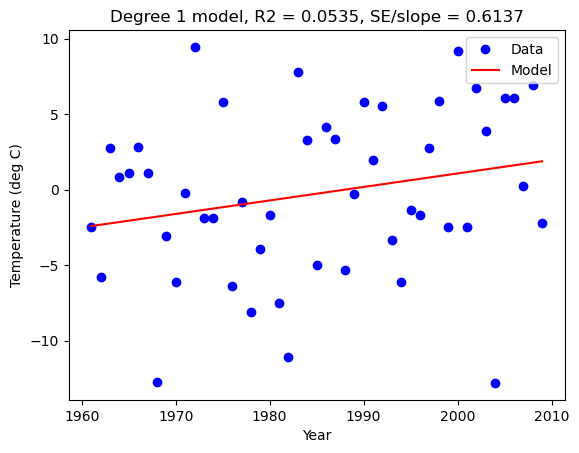

In [7]:
# Step 1: Load climate data and extract January 10th temperatures
climate = Climate('data.csv')
city = 'NEW YORK'
years = pylab.array(TRAINING_INTERVAL)
jan10_temps = []

for year in years:
    # Get temperature for January 10th (month=1, day=10)
    temp = climate.get_daily_temp(city, month=1, day=10, year=year)
    jan10_temps.append(temp)
jan10_temps = pylab.array(jan10_temps)

# Step 2: Fit linear model (degree=1)
models_jan10 = generate_models(years, jan10_temps, [1])

# Step 3: Visualize and evaluate
evaluate_models_on_training(years, jan10_temps, models_jan10)

### New York: annual means

Average all available daily records in each year before fitting. The provided data contain complete calendars, including leap days.

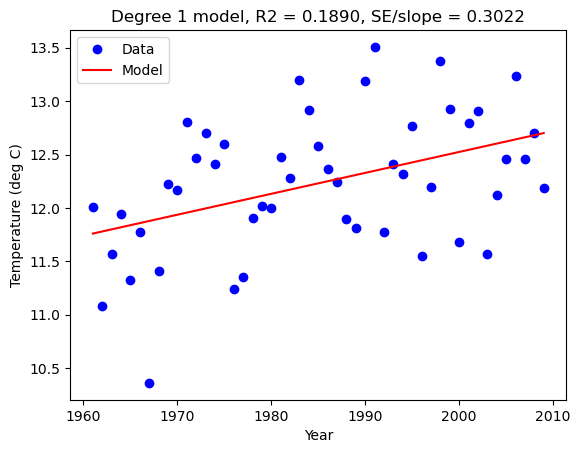

In [8]:
# Step 1: Calculate average annual temperature for each year
annual_avg_temps = []
for year in years:
    # Get daily temperatures for the year, then compute mean
    daily_temps = climate.get_yearly_temp(city, year)
    annual_avg = daily_temps.mean()
    annual_avg_temps.append(annual_avg)
annual_avg_temps = pylab.array(annual_avg_temps)

# Step 2: Fit linear model (degree=1)
models_annual = generate_models(years, annual_avg_temps, [1])

# Step 3: Visualize and evaluate
evaluate_models_on_training(years, annual_avg_temps, models_annual)

## 2. Multi-city annual means

The fixed-day and annual-mean fits have $R^2$ approximately 0.0535 and 0.1890. Next, `gen_cities_avg` averages each city’s annual mean with equal city weights. Variables named `national_*` denote this 21-city cohort with equal city weights; they are not a population- or area-weighted national estimate.

In [9]:
def gen_cities_avg(climate, multi_cities, years):
    """
    Compute the average annual temperature over multiple cities.

    Args:
        climate: instance of Climate
        multi_cities: the names of cities we want to average over (list of str)
        years: the range of years of the yearly averaged temperature (list of
            int)

    Returns:
        a pylab 1-d array of floats with length = len(years). Each element in
        this array corresponds to the average annual temperature over the given
        cities for a given year.
    """
    yearly_avgs = []
    for year in years:
        city_means = []
        for city in multi_cities:
            temps = climate.get_yearly_temp(city, year)
            city_means.append(temps.mean())
        yearly_avgs.append(sum(city_means) / len(city_means))
    return pylab.array(yearly_avgs)

### Existing aggregation checks

Compare Seattle and the full cohort with saved expected annual means for 2010–2015.

In [10]:
# Test 1: Single city (Seattle, testing interval 2010–2015)
test_years = pylab.array(TESTING_INTERVAL)
seattle_avg = gen_cities_avg(climate, ['SEATTLE'], test_years)
correct_seattle = [11.514, 10.587, 11.283, 12.106, 12.829, 13.132]
assert all(math.isclose(seattle_avg[i], correct_seattle[i], rel_tol=0.01) 
           for i in range(len(seattle_avg))), "Single-city average mismatch"

# Test 2: Multiple cities (all 21 cities, testing interval)
national_avg = gen_cities_avg(climate, CITIES, test_years)
correct_national = [16.760, 16.857, 17.562, 16.657, 16.845, 17.545]
assert all(math.isclose(national_avg[i], correct_national[i], rel_tol=0.01) 
           for i in range(len(national_avg))), "Multi-city average mismatch"

print("All gen_cities_avg tests passed!")

All gen_cities_avg tests passed!


### Aggregated annual trend

Fit a linear model to the cohort’s annual means for 1961–2009. The original saved result has $R^2$ approximately 0.7462.

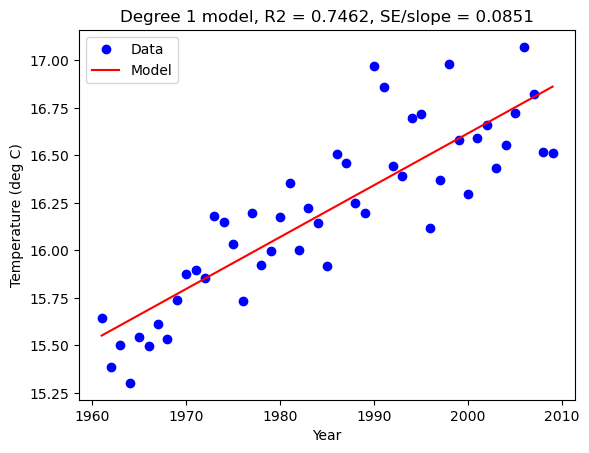

In [11]:
# Step 1: Compute national average temperatures (1961–2009)
national_temps = gen_cities_avg(climate, CITIES, TRAINING_INTERVAL)
years = pylab.array(TRAINING_INTERVAL)

# Step 2: Fit linear model
models_national = generate_models(years, national_temps, [1])

# Step 3: Visualize
evaluate_models_on_training(years, national_temps, models_national)

## 3. Trailing moving average

`moving_average` includes the current observation and up to four prior years. At the beginning of a segment it uses all available observations, so the first four windows are shorter than five years. The implementation assumes a positive window length.

In [12]:
def moving_average(y, window_length):
    """
    Compute the moving average of y with specified window length.

    Args:
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        window_length: an integer indicating the window length for computing
            moving average

    Returns:
        an 1-d pylab array with the same length as y storing moving average of
        y-coordinates of the N sample points
    """
    avgs = []
    for i in range(len(y)):
        if i < window_length - 1:
            window = y[:i+1]
        else:
            window = y[i - window_length + 1:i+1]
        avgs.append(window.mean())
    return pylab.array(avgs)

### Existing window checks

The assertions cover windows of length two and three, including negative observations.

In [13]:
# Test 1: Simple window=3 case
y = pylab.array([1, 2, 3, 4, 5, 6, 7])
window = 3
correct = pylab.array([1, 1.5, 2, 3, 4, 5, 6])
result = moving_average(y, window)
assert list(result) == list(correct), "Moving average mismatch (Test 1)"

# Test 2: Window=2 with negative values
y = pylab.array([-1.5, 1.5, -3.0, 3.0, -4.5, 4.5])
window = 2
correct = pylab.array([-1.5, 0, -0.75, 0, -0.75, 0])
result = moving_average(y, window)
assert list(result) == list(correct), "Moving average mismatch (Test 2)"

print("All moving_average tests passed!")

All moving_average tests passed!


### Smoothed training trend

Apply the moving average to the 1961–2009 cohort series and fit a line. The original saved $R^2$ is approximately 0.9250. This evaluates a transformed target; it does not establish a predictive improvement over the unsmoothed target.

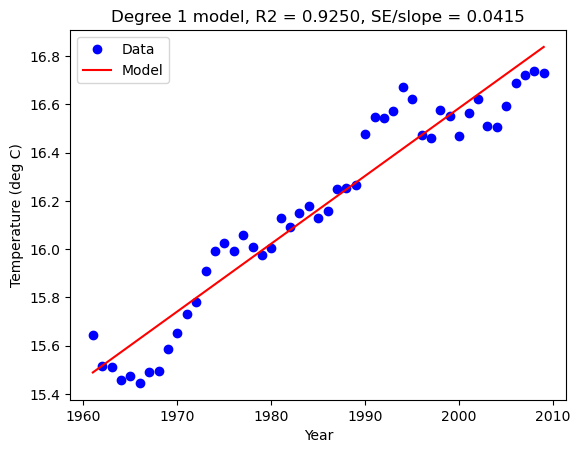

In [14]:
# Step 1: Compute 5-year moving average of national temperatures
window_length = 5
national_ma = moving_average(national_temps, window_length)

# Step 2: Fit linear model to smoothed data
models_ma = generate_models(years, national_ma, [1])

# Step 3: Visualize
evaluate_models_on_training(years, national_ma, models_ma)

## 4. Prediction error

`rmse` computes the square root of mean squared residuals. Training uses 1961–2009 and testing uses 2010–2015. The evaluated target is the smoothed cohort annual mean.

In [15]:
def rmse(y, estimated):
    """
    Calculate the root mean square error term.

    Args:
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        estimated: an 1-d pylab array of values estimated by the regression
            model

    Returns:
        a float for the root mean square error term
    """
    return pylab.sqrt(((y - estimated) ** 2).mean())

### Test plots

`evaluate_models_on_testing` shows held-out observations and predictions with RMSE, using the models fitted on training years.

In [16]:
def evaluate_models_on_testing(x, y, models):
    """
    For each regression model, compute the RMSE for this model and plot the
    test data along with the model’s estimation.

    For the plots, you should plot data points (x,y) as blue dots and your best
    fit curve (aka model) as a red solid line. You should also label the axes
    of this figure appropriately and have a title reporting the following
    information:
        degree of your regression model,
        RMSE of your model evaluated on the given data points. 

    Args:
        x: an 1-d pylab array with length N, representing the x-coordinates of
            the N sample points
        y: an 1-d pylab array with length N, representing the y-coordinates of
            the N sample points
        models: a list containing the regression models you want to apply to
            your data. Each model is a pylab array storing the coefficients of
            a polynomial.

    Returns:
        None
    """
    for model in models:
        estimated = pylab.polyval(model, x)
        error = rmse(y, estimated)
        pylab.figure()
        pylab.plot(x, y, 'bo', label='Data')
        pylab.plot(x, estimated, 'r-', label='Model')
        pylab.xlabel('Year')
        pylab.ylabel('Temperature (deg C)')
        deg = len(model) - 1
        pylab.title(f'Degree {deg} model, RMSE = {error:.4f}')
        pylab.legend()
        pylab.show()

### Existing RMSE checks

The original assertions compare two calculated errors with known values.

In [17]:
# Test 1: Large prediction errors
y = pylab.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
estimated = pylab.array([1, 4, 9, 16, 25, 36, 49, 64, 81])
correct_rmse = 35.8515
assert math.isclose(rmse(y, estimated), correct_rmse, rel_tol=0.001), "RMSE mismatch (Test 1)"

# Test 2: All actual values = 1
y = pylab.array([1]*9)
correct_rmse = 40.5134
assert math.isclose(rmse(y, estimated), correct_rmse, rel_tol=0.001), "RMSE mismatch (Test 2)"

print("All rmse tests passed!")

All rmse tests passed!


### Model complexity comparison

Fit degrees 1, 2 and 20 to the same training target. Degree 20 is deliberately retained as a comparison and produces a conditioning warning. High training $R^2$ alone is not evidence of good extrapolation.

  model = pylab.polyfit(x, y, deg)


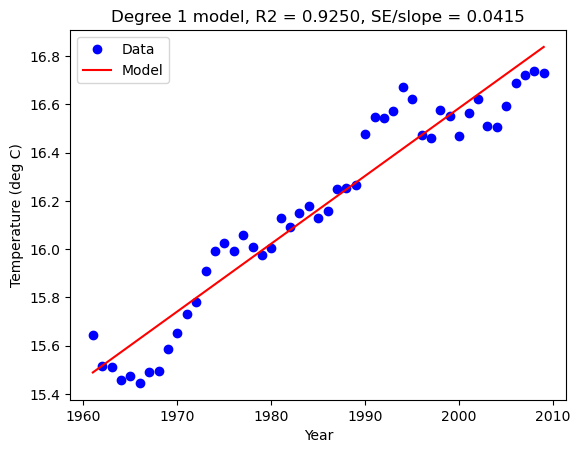

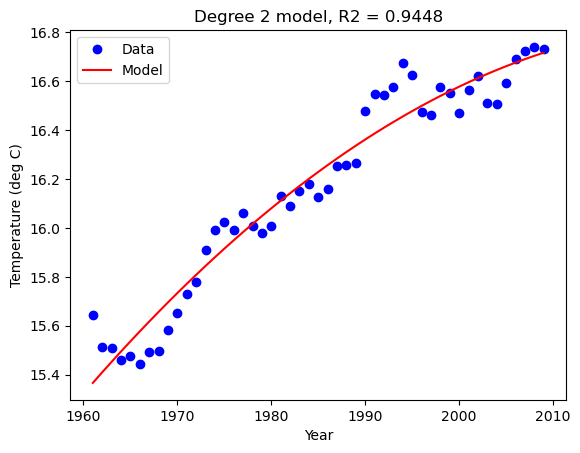

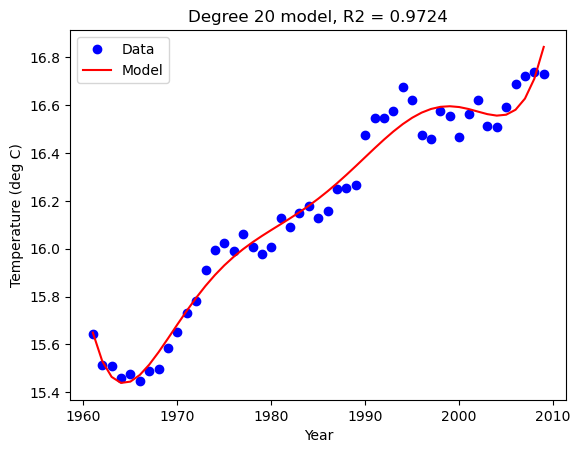

In [18]:
# Step 1: Get smoothed training data (from 3)
training_years = pylab.array(TRAINING_INTERVAL)
training_ma = national_ma  # 5-year MA of 1961–2009 national temps

# Step 2: Train models for degrees 1, 2, 20
models_pred = generate_models(training_years, training_ma, [1, 2, 20])

# Step 3: Visualize fits on training data
evaluate_models_on_training(training_years, training_ma, models_pred)

### Held-out evaluation

The original code computes the moving average separately for the test segment. Consequently, 2010–2013 use one-, two-, three- and four-year windows. This defines the evaluation target for this experiment; changing to a continuous window across the split would create a different experiment.

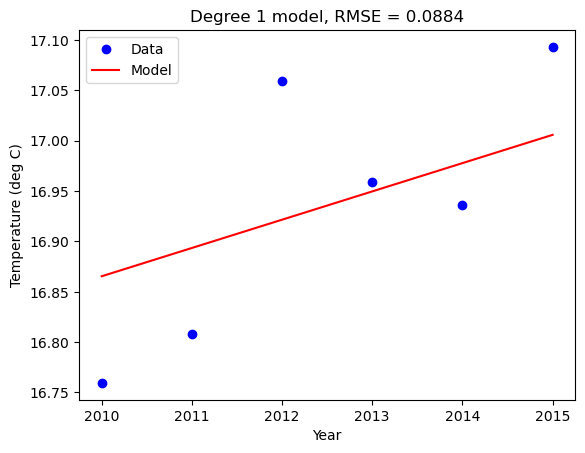

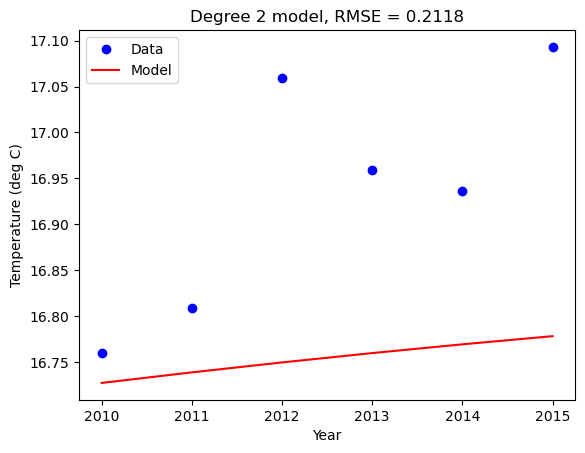

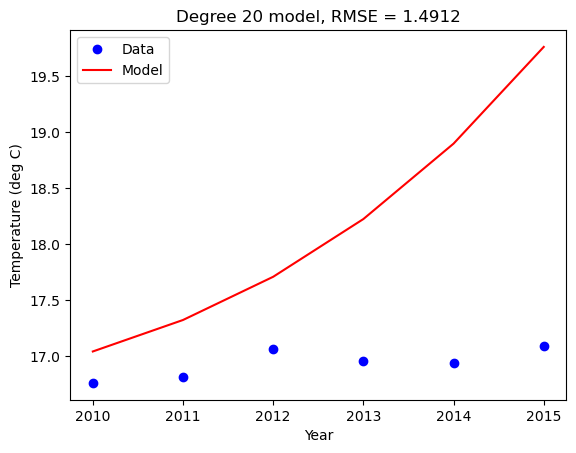

In [19]:
# Step 1: Compute 2010–2015 national temperatures (test data)
test_years = pylab.array(TESTING_INTERVAL)
test_national = gen_cities_avg(climate, CITIES, test_years)

# Step 2: Compute 5-year moving average of test data
test_ma = moving_average(test_national, window_length=5)

# Step 3: Evaluate models on test data
evaluate_models_on_testing(test_years, test_ma, models_pred)

## 5. Within-year temperature variability

The original saved test RMSE values are 0.0884, 0.2118 and 1.4912 °C for degrees 1, 2 and 20. There are only six test years. High-degree results can vary with the numerical environment.

`gen_std_devs` first averages cities on each day, then computes the population standard deviation of those daily means within the year. Its original docstring is imprecise; this is not the standard deviation across cities’ annual means.

In [20]:
def gen_std_devs(climate, multi_cities, years):
    """
    For each year in years, compute the standard deviation over the averaged yearly
    temperatures for each city in multi_cities. 

    Args:
        climate: instance of Climate
        multi_cities: the names of cities we want to use in our std dev calculation (list of str)
        years: the range of years to calculate standard deviation for (list of int)

    Returns:
        a pylab 1-d array of floats with length = len(years). Each element in
        this array corresponds to the standard deviation of the average annual 
        city temperatures for the given cities in a given year.
    """
    std_devs = []
    for year in years:
        city_temps = []
        for city in multi_cities:
            temps = climate.get_yearly_temp(city, year)
            city_temps.append(temps)
        city_temps = pylab.array(city_temps)
        daily_means = city_temps.mean(axis=0)
        std_devs.append(daily_means.std())
    return pylab.array(std_devs)


### Existing variability check

The original assertions check Seattle’s 1961 and 2009 standard deviations.

In [21]:
# Test: Single city (Seattle, training interval 1961–2009)
seattle_std = gen_std_devs(climate, ['SEATTLE'], TRAINING_INTERVAL)
correct_first = 6.1119  # Expected std for 1961
correct_last = 6.5696   # Expected std for 2009
assert math.isclose(seattle_std[0], correct_first, rel_tol=0.01), "Std dev mismatch (1961)"
assert math.isclose(seattle_std[-1], correct_last, rel_tol=0.01), "Std dev mismatch (2009)"

print("gen_std_devs test passed!")

gen_std_devs test passed!


### Variability trend

Smooth the yearly variability sequence and fit a line. This quantity contains seasonal variation and can suppress regional extremes through averaging; it is not an extreme-event frequency measure.

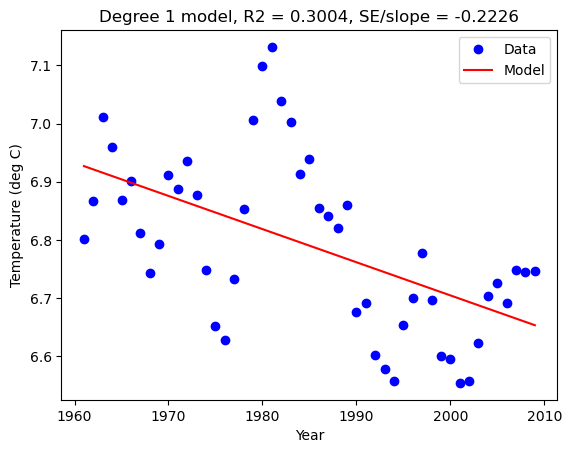

In [22]:
# Step 1: Compute annual standard deviations (all 21 cities, 1961–2009)
annual_std = gen_std_devs(climate, CITIES, TRAINING_INTERVAL)
years = pylab.array(TRAINING_INTERVAL)

# Step 2: Smooth with 5-year moving average
std_ma = moving_average(annual_std, window_length=5)

# Step 3: Fit linear model and visualize
models_std = generate_models(years, std_ma, [1])
evaluate_models_on_training(years, std_ma, models_std)

### Interpretation

The saved variability trend slopes downward under this proxy. It does not establish that extreme weather is becoming less frequent. The raw-data anomaly and evaluation assumptions are documented in [data notes](docs/data.md) and [analysis notes](docs/analysis.md).

## 6. Possible applications

The original report proposed energy planning, manufacturing resilience, industrial emissions planning and urban heat resilience applications. These are discussion proposals, not implemented systems or trained deep-learning models. See [application discussion](docs/analysis.md#possible-applications).